# ESC Throughput Budget Tool

Every throughput element added to an `Observatory` is recorded, and two methods read that record:

- `get_throughput_budget(wavelength, bandpass=..., components=...)`: each component's throughput and the cumulative throughput, as a table.
- `plot_throughput_budget(wavelengths, bandpass=..., components=...)`: component curves, cumulative curves and the final ETC bandpass.

Pass `components=` one name or a list of names to see only those components.

Files changed:
- `src/stp_etc_esc/ExposureTimeSNRCalculatorESC.py`: component registry and the two methods
- `tests/test_bandpass_scope_synthetic.py`: synthetic tests
- `tests/regression/` + `tests/test_data/`: UM regression check and baseline
- `notebooks/ESC_ThroughputBudget_Demo.ipynb`: this demo

In [1]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import config_stp_esc
from stp_etc_esc import ExposureTimeSNRCalculatorESC as etsc

# Component curves shipped with config_stp_esc.
data = Path(config_stp_esc.get_data_path())
config = config_stp_esc.load_config_values()
arm = config["common_params"]["arm_a"]
sensor = arm["sensor"]

obs = etsc.Observatory(telescope_name="ESC", telescope_diameter=3.0 * u.m,
                       telescope_focal_len=110 * u.m)
obs.primary_filter = 6300 * u.AA    # sets the FPM's lambda/D scale
obs.instrument_config = config      # add_sensor() reads its noise curves
obs.instrument_SP = data

obs.add_mirror((data / arm["optics"]["oap1"]["coating_refl"]).as_posix(),
               num_curves=3, name="oaps", group="instrument")
obs.add_generic_filter(6300 * u.AA, fbw=0.02, name="filter",
                       group="instrument")
obs.add_transmissive_optic(
    (data / arm["optics"]["lp1"]["pol_throughput"]).as_posix(),
    wave_unit="nm", name="polarizer", group="instrument")
obs.add_lamD_optic(
    (data / arm["optics"]["fpm"]["throughput"]).as_posix(),
    config["common_params"]["sources"]["companion"]["separation"],
    coronOnly=True, name="fpm", group="instrument")
obs.add_sensor((data / sensor["qe"]).as_posix(), gain_setting=sensor["gain"],
               sensor_temp=sensor["temp_nominal"] * u.Celsius,
               name="detector_qe", group="detector")

In [2]:
budget = obs.get_throughput_budget(6300 * u.AA)
budget[["name", "group", "throughput", "cumulative_throughput"]]

,name,group,throughput,cumulative_throughput
0,oaps,instrument,0.748175,0.748175
1,filter,instrument,0.980000,0.733211
2,polarizer,instrument,0.717964,0.526419
3,fpm,instrument,0.580244,0.305451
4,detector_qe,detector,0.651319,0.198946


,name,throughput,cumulative_throughput
0,detector_qe,0.651319,0.198946


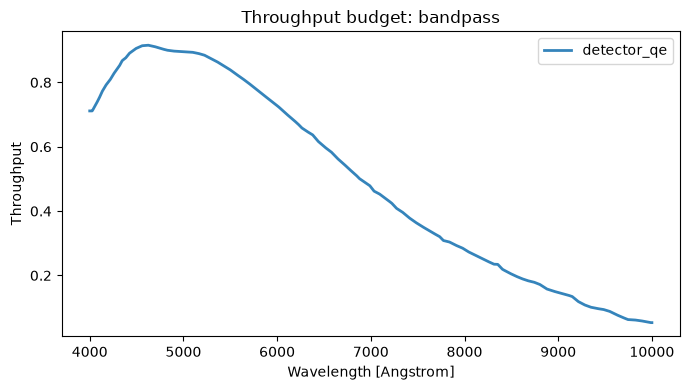

In [3]:
qe = obs.get_throughput_budget(6300 * u.AA, components="detector_qe")
display(qe[["name", "throughput", "cumulative_throughput"]])

wavelengths = np.arange(4000, 10001, 5) * u.AA
fig, ax = plt.subplots(figsize=(7, 4))
obs.plot_throughput_budget(wavelengths, components="detector_qe",
                           show_cumulative=False, show_final=False, ax=ax)
ax.legend()
plt.tight_layout()

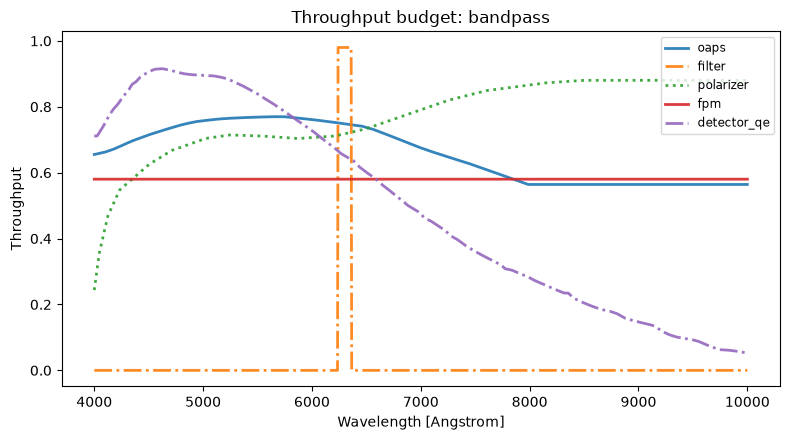

In [4]:
selected = ["oaps", "filter", "polarizer", "fpm", "detector_qe"]

fig, ax = plt.subplots(figsize=(8, 4.5))
obs.plot_throughput_budget(wavelengths, components=selected,
                           show_cumulative=False, show_final=False, ax=ax)
ax.legend(fontsize="small")
plt.tight_layout()

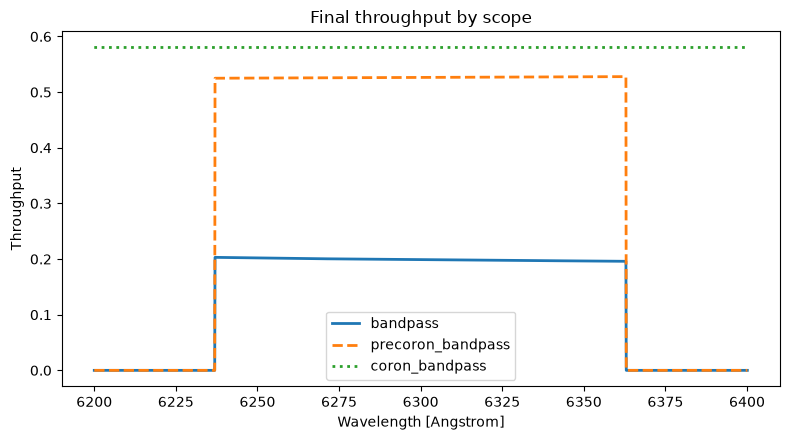

In [5]:
science_band = np.arange(6200, 6400.1, 0.1)

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, style in [("bandpass", "-"), ("precoron_bandpass", "--"),
                    ("coron_bandpass", ":")]:
    curve = getattr(obs, name)(science_band * u.AA).value
    ax.plot(science_band, curve, linestyle=style, linewidth=2, label=name)
ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("Throughput")
ax.set_title("Final throughput by scope")
ax.legend()
plt.tight_layout()

Bandpass regression and count-rate scaling are validated by the test suite in `tests/`.